# Causal weighting: rescuing the continuous-time network beyond one lap

**Purpose.** In `../Initial_pass` the paper's continuous-time technique (Raissi, Perdikaris &
Karniadakis, J. Comput. Phys. **378** (2019) 686–707, section 3.1) failed on van der Pol
beyond about one lap of the limit cycle: the optimiser converged onto *spurious solutions* —
mostly the repelling equilibrium at the origin, which satisfies the equation exactly — while
the training loss looked converged. The diagnosis: the loss fits all times simultaneously, so
late times settle onto an impostor before any information from the single anchor at $t=0$
reaches them. The missing ingredient is not more physics but **causality** — an initial-value
problem is determined forward in time.

**The change.** Causal weighting (Wang, Sankaran & Perdikaris, arXiv:2203.07404) encodes
exactly that, and nothing else. The residual at collocation time $t_i$ is weighted by

$$ w_i \;=\; \exp\!\Big(-\varepsilon \int_0^{t_i} |r(s)|^2\, ds\Big), \qquad \varepsilon = 5, $$

(the integral taken as a left Riemann sum over the sorted collocation times): a point only
counts once the trajectory *before* it already satisfies the equation. A front of solved
trajectory propagates outward from the anchor, and the impostor can no longer capture the far
end early. On convergence all residuals vanish, every weight rises to 1, and the objective
**becomes exactly the Initial_pass loss** — the weighting is scaffolding that dismantles itself,
and the trained network is unchanged in kind: still a continuous map $t \mapsto (y_1, y_2)$.

**What is held fixed.** Everything else: architecture (4 hidden layers of 50 tanh units,
float64), collocation density (20 points per unit time, stratified uniform), horizons
$T \in \{3, 7, 14, 27, 40\}$, three seeds each, the L-BFGS budget (6 restarts × 200
iterations), the start $(2, 0)$, and the metric — relative L2 against the RK_Truth reference,
which is never trained on. Whatever changes below is attributable to causal weighting alone.

**How it is trained.** Two phases, following the causal-weighting paper. First **front
propagation**: Adam, with the weights recomputed at every iteration and $\varepsilon$
annealed upward through $\{10^{-2}, 10^{-1}, 1, 10, 100\}$ — small $\varepsilon$ tolerates
upstream error, large $\varepsilon$ demands it be gone — advancing whenever the smallest
weight exceeds 0.99. The front must move *continuously*: freezing the weights per L-BFGS
restart stalled mid-domain at $T=14$ under two different budget splits (6×200 iterations:
42% awake; 40×30: 32%), because L-BFGS needs a stationary objective and the front can only
advance at a refreeze. Second, **polish**: once every weight is ~1 at the final
$\varepsilon$, the objective *is* the unweighted Initial_pass loss, and the identical
Initial_pass L-BFGS loop (6 restarts × 200 iterations, same early stopping) finishes on it.
Causal weighting is thus a warm start that delivers L-BFGS into the right basin; both sides
of the comparison end up optimising the same objective with the same optimiser.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
import model as m
import training as tr

FIGURES = Path.cwd() / "figures"
FIGURES.mkdir(exist_ok=True)
RESULTS = tr.RESULTS

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25,
})
print(f"epsilon schedule = {tr.EPSILONS}, horizons = {tr.HORIZONS}, seeds = {tr.SEEDS}")

epsilon schedule = (0.01, 0.1, 1.0, 10.0, 100.0), horizons = (3.0, 7.0, 14.0, 27.0, 40.0), seeds = (0, 1, 2)


## The sweep

Same driver as Initial_pass: every (horizon, seed) is trained and scored, results are saved
after every run, and a finished sweep just reloads. Delete `results/` to retrain.

In [2]:
summary = tr.run_sweep()
summary

  resuming: 15 of 15 runs already saved


,horizon,laps,seed,n_collocation,adam_steps_used,front_arrived,lbfgs_restarts,seconds,loss_total,loss_start,loss_residual,rel_l2
0,3.0,0.450228,0,60,3501,True,3,29.9,2.882989e-07,3.356700e-12,2.882955e-07,0.000048
1,3.0,0.450228,1,60,3001,True,3,25.0,1.717969e-07,1.422859e-12,1.717955e-07,0.000031
2,3.0,0.450228,2,60,5501,True,3,38.6,1.796694e-07,6.991076e-12,1.796624e-07,0.000067
3,7.0,1.050533,0,140,28501,True,4,223.8,2.655703e-07,2.556449e-12,2.655678e-07,0.000135
4,7.0,1.050533,1,140,8501,True,4,73.3,6.527065e-07,2.024873e-14,6.527065e-07,0.000076
5,7.0,1.050533,2,140,14001,True,6,116.7,2.773306e-07,2.347992e-13,2.773304e-07,0.000061
6,14.0,2.101065,0,280,60000,False,6,573.8,7.428522e-07,1.649006e-11,7.428357e-07,0.000212
7,14.0,2.101065,1,280,60000,False,6,583.0,3.542460e-07,8.838511e-15,3.542460e-07,0.000107
8,14.0,2.101065,2,280,60000,False,6,593.4,9.667277e-06,1.445587e-08,9.652822e-06,0.714772
9,27.0,4.052054,0,540,60000,False,6,896.9,5.091486e-04,4.532841e-06,5.046158e-04,0.877828


In [3]:
initial = tr.load_initial_pass()
predictions = dict(np.load(RESULTS / "predictions.npz"))
weight_profiles = dict(np.load(RESULTS / "weight_profiles.npz"))
histories = pd.read_csv(RESULTS / "training_histories.csv")

def median_seed(df, horizon):
    g = df[df.horizon == horizon].sort_values("rel_l2")
    return int(g.iloc[len(g) // 2].seed)

LAP = tr.LAP
HORIZONS = list(tr.HORIZONS)

## Figure 1 — the causal front, advancing

The mechanism itself, on two showcases: the cliff horizon $T=14$ (where Initial_pass
collapsed, all seeds) and the hardest horizon $T=40$. **Top row:** snapshots of the weight
profile $w(t)$ during the Adam phase (colour = training step) — the front of "awake"
collocation points starts at the anchor and sweeps right as the trajectory behind it becomes
consistent with the equation. **Bottom row:** the magnitude of the equation residual along
the final fit. If the method works, the residual is small *everywhere*, not just in an escape
window — compare Initial_pass, where the residual was paid only while the fit fled to the
equilibrium and was silent on the impostor.

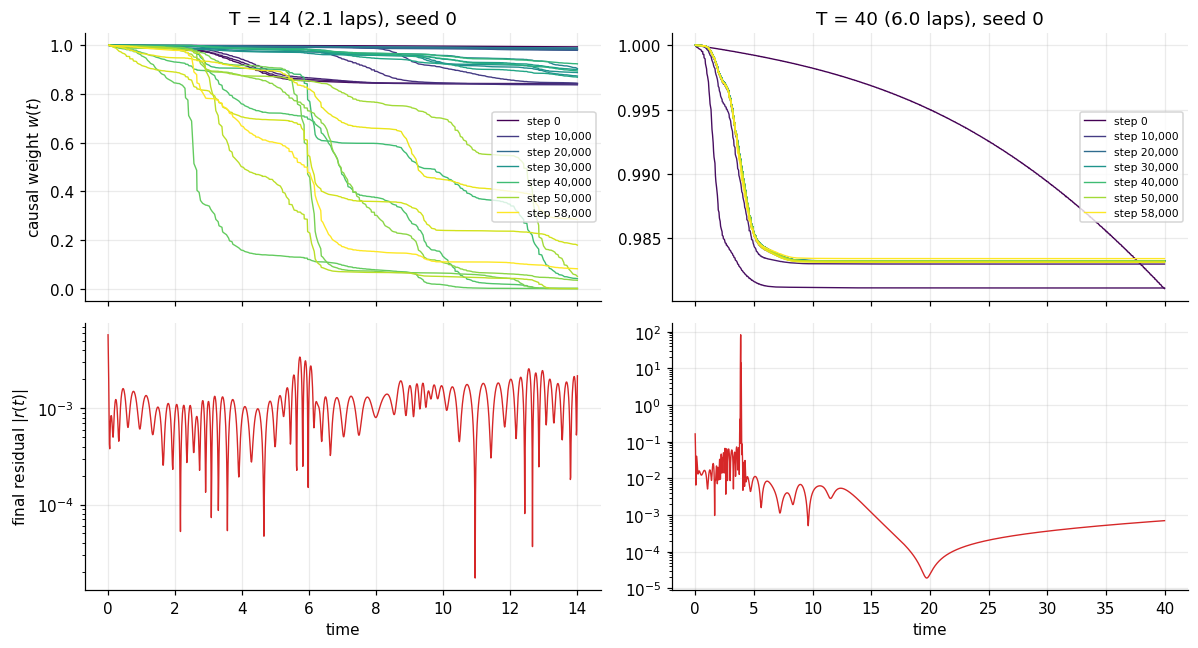

In [4]:
showcases = [(14.0, 0), (40.0, 0)]
fig, axes = plt.subplots(2, len(showcases), figsize=(11, 6), sharex="col")
for j, (T, seed) in enumerate(showcases):
    key = f"T{T:g}_seed{seed}"
    W = weight_profiles[f"{key}_weights"]          # (snapshots, N)
    steps = weight_profiles[f"{key}_steps"]
    tc = weight_profiles[f"{key}_times"]
    cmap = plt.get_cmap("viridis")
    for k, w in enumerate(W):
        axes[0, j].plot(tc, w, color=cmap(k / max(len(W) - 1, 1)), lw=0.9,
                        label=(f"step {steps[k]:,}" if k % max(len(W)//6, 1) == 0
                               or k == len(W) - 1 else None))
    axes[0, j].set_title(f"T = {T:g} ({T/LAP:.1f} laps), seed {seed}")
    axes[0, j].set_ylabel("causal weight $w(t)$" if j == 0 else "")
    axes[0, j].legend(fontsize=7, loc="center right")

    t_grid = predictions[f"t_T{T:g}"]
    axes[1, j].semilogy(t_grid, predictions[f"{key}_residual"], color="C3", lw=0.9)
    axes[1, j].set_ylabel("final residual $|r(t)|$" if j == 0 else "")
    axes[1, j].set_xlabel("time")
fig.tight_layout()
fig.savefig(FIGURES / "01_causal_front.png", bbox_inches="tight")
plt.show()

## Figure 2 — training curves

**Top:** the unweighted total loss (the Initial_pass objective, so directly comparable)
during the Adam front-propagation phase, per seed; the square marker at the right edge is
where the L-BFGS polish finished. The grey dashed line is where Initial_pass finished
(median over its seeds): at the long horizons that level was a *converged wrong answer*, so
finishing well below it is the signature of escaping the impostor. The unweighted loss is
allowed to be large mid-phase — the sleeping region doesn't count yet and can be arbitrarily
wrong until the front reaches it. **Bottom:** the awake fraction (share of collocation
points with $w > 0.5$) — the front's position as it crosses the domain.

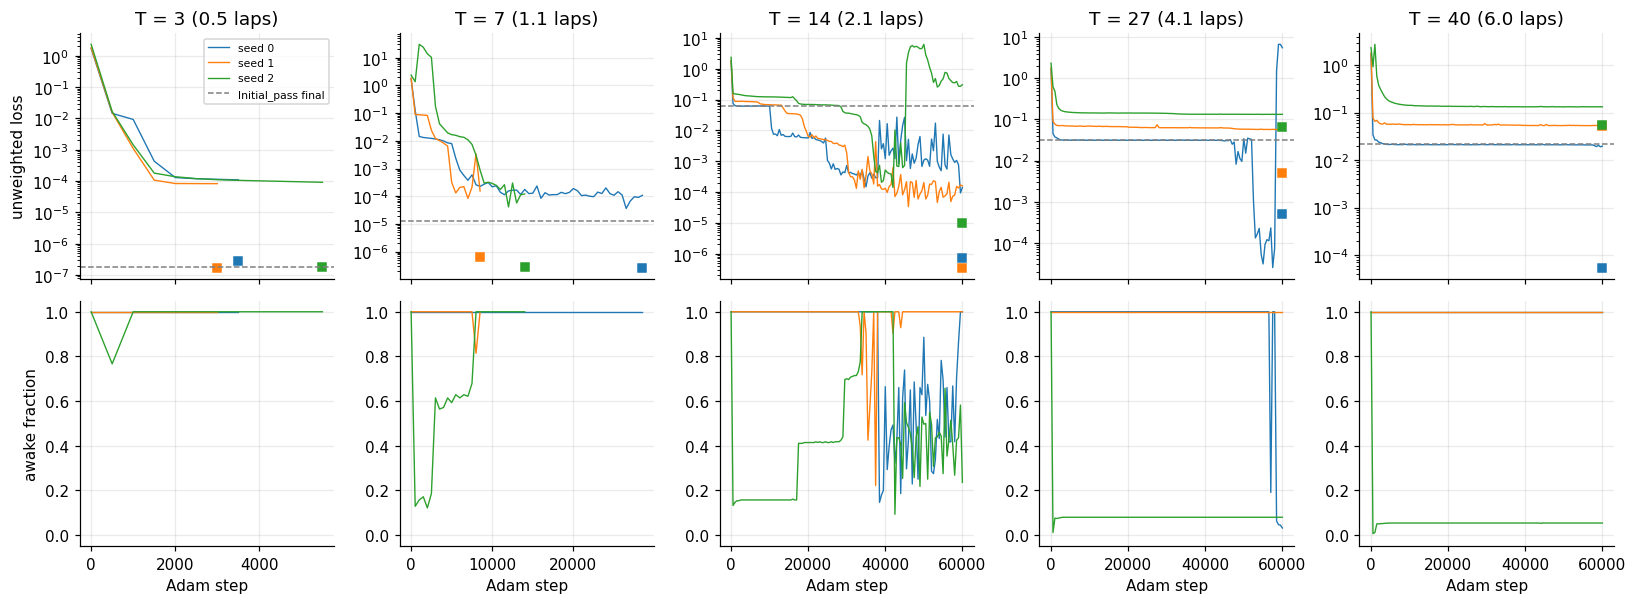

In [5]:
fig, axes = plt.subplots(2, len(HORIZONS), figsize=(15, 5.6), sharex="col")
for j, T in enumerate(HORIZONS):
    for seed, colour in zip(tr.SEEDS, ["C0", "C1", "C2"]):
        h = histories[(histories.horizon == T) & (histories.seed == seed)]
        a = h[h.phase == "adam"]
        axes[0, j].semilogy(a.step, a.loss_total, color=colour, lw=0.9,
                            label=f"seed {seed}")
        final = h[h.phase == "lbfgs"].loss_total.iloc[-1]
        axes[0, j].semilogy([a.step.max()], [final], "s", color=colour, ms=5)
        axes[1, j].plot(a.step, a.awake_fraction, color=colour, lw=0.9)
    ref = initial[initial.horizon == T].loss_total.median()
    axes[0, j].axhline(ref, color="grey", ls="--", lw=1,
                       label="Initial_pass final" if j == 0 else None)
    axes[0, j].set_title(f"T = {T:g} ({T/LAP:.1f} laps)")
    axes[1, j].set_xlabel("Adam step")
    axes[1, j].set_ylim(-0.05, 1.05)
axes[0, 0].set_ylabel("unweighted loss")
axes[1, 0].set_ylabel("awake fraction")
axes[0, 0].legend(fontsize=7)
fig.tight_layout()
fig.savefig(FIGURES / "02_training_loss.png", bbox_inches="tight")
plt.show()

## Figure 3 — the headline: error vs horizon, with and without causal weighting

Relative L2 error against the reference, per run (markers) and through the seed-medians
(lines). This is the same metric, reference, budget and density on both sides; only the
weighting differs. Initial_pass fell off a cliff between one and two laps; the question this
figure answers is whether causality removes the cliff.

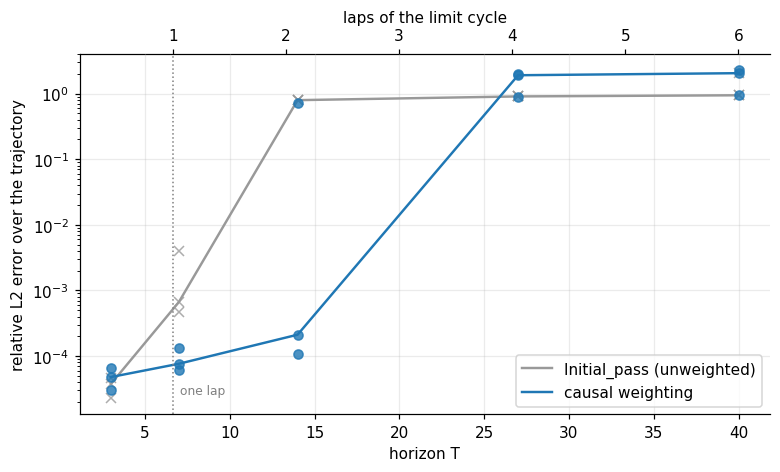

In [6]:
fig, ax = plt.subplots(figsize=(7.2, 4.4))
for df, colour, marker, label in [(initial, "0.6", "x", "Initial_pass (unweighted)"),
                                  (summary, "C0", "o", "causal weighting")]:
    ax.semilogy(df.horizon, df.rel_l2, marker, color=colour, ms=6, alpha=0.8)
    med = df.groupby("horizon").rel_l2.median()
    ax.semilogy(med.index, med.values, "-", color=colour, lw=1.6, label=label)
ax.axvline(LAP, color="grey", ls=":", lw=1)
ax.text(LAP + 0.4, ax.get_ylim()[0] * 2, "one lap", color="grey", fontsize=8)
ax.set_xlabel("horizon T")
ax.set_ylabel("relative L2 error over the trajectory")
ax.legend()
top = ax.secondary_xaxis("top", functions=(lambda x: x / LAP, lambda x: x * LAP))
top.set_xlabel("laps of the limit cycle")
fig.tight_layout()
fig.savefig(FIGURES / "03_error_vs_horizon_comparison.png", bbox_inches="tight")
plt.show()

## Figure 4 — the fits themselves

$y_1(t)$: network (colour, dashed) against the reference (black), one panel per horizon, at
the median seed. In Initial_pass these panels showed the fit peeling off after roughly one
lap and decaying into the origin.

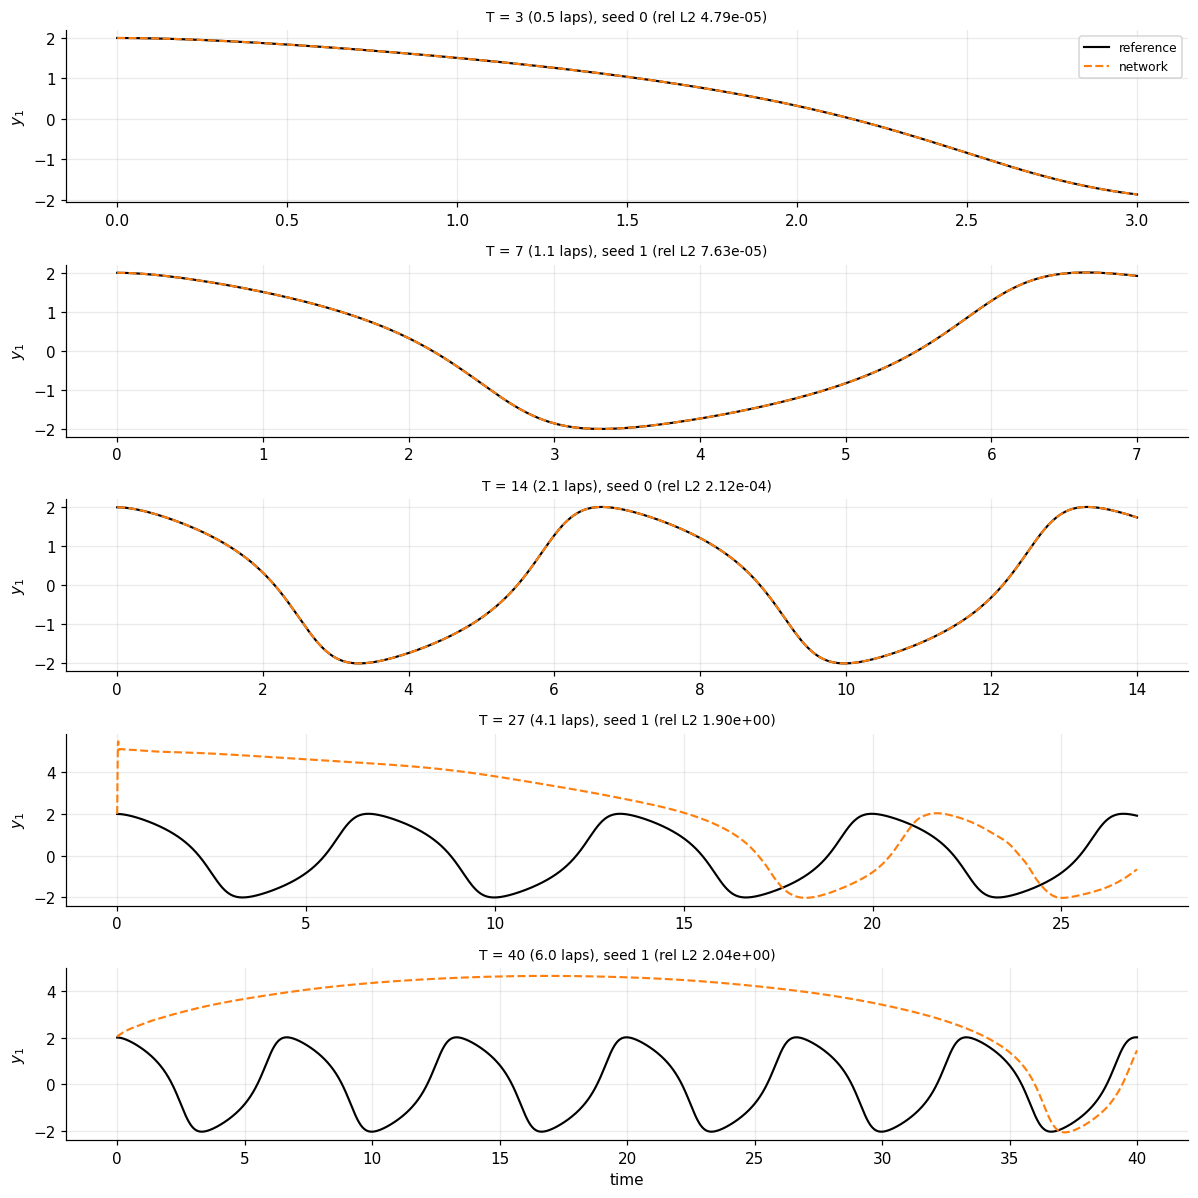

In [7]:
fig, axes = plt.subplots(len(HORIZONS), 1, figsize=(11, 11), sharex=False)
for ax, T in zip(axes, HORIZONS):
    seed = median_seed(summary, T)
    key = f"T{T:g}_seed{seed}"
    t = predictions[f"t_T{T:g}"]
    t_ref, y_ref = tr.load_reference()
    mask = t_ref <= T + 1e-9
    ax.plot(t_ref[mask], y_ref[mask][:, 0], "k-", lw=1.4, label="reference")
    ax.plot(t, predictions[f"{key}_y_net"][:, 0], "--", color="C1", lw=1.4,
            label="network")
    ax.set_ylabel("$y_1$")
    ax.set_title(f"T = {T:g} ({T/LAP:.1f} laps), seed {seed} "
                 f"(rel L2 {summary[(summary.horizon==T)&(summary.seed==seed)].rel_l2.iloc[0]:.2e})",
                 fontsize=9)
axes[0].legend(fontsize=8)
axes[-1].set_xlabel("time")
fig.tight_layout()
fig.savefig(FIGURES / "04_fits_by_horizon.png", bbox_inches="tight")
plt.show()

## Figure 5 — phase portraits

The same runs in the $(y_1, y_2)$ plane. A correct fit traces the limit cycle on top of the
reference; the Initial_pass failures spiralled into the origin (the repelling equilibrium,
marked ×) or wandered off the loop entirely.

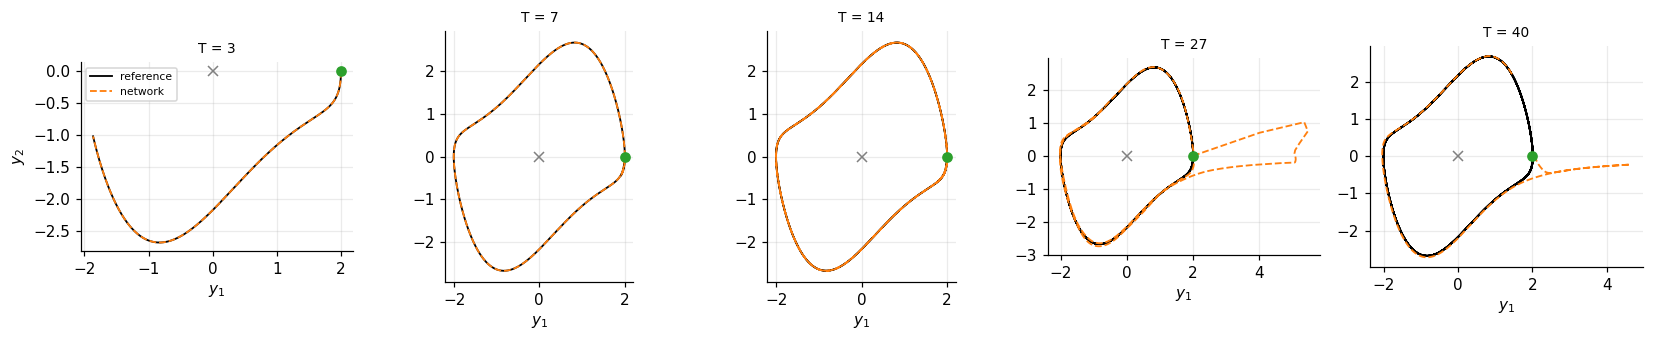

In [8]:
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(15, 3.2))
for ax, T in zip(axes, HORIZONS):
    seed = median_seed(summary, T)
    key = f"T{T:g}_seed{seed}"
    t_ref, y_ref = tr.load_reference()
    mask = t_ref <= T + 1e-9
    ax.plot(y_ref[mask][:, 0], y_ref[mask][:, 1], "k-", lw=1.2, label="reference")
    yn = predictions[f"{key}_y_net"]
    ax.plot(yn[:, 0], yn[:, 1], "--", color="C1", lw=1.2, label="network")
    ax.plot(*m.START, "o", color="C2", ms=6)
    ax.plot(0, 0, "x", color="grey", ms=6)
    ax.set_title(f"T = {T:g}", fontsize=9)
    ax.set_xlabel("$y_1$")
    ax.set_aspect("equal")
axes[0].set_ylabel("$y_2$")
axes[0].legend(fontsize=7)
fig.tight_layout()
fig.savefig(FIGURES / "05_phase_by_horizon.png", bbox_inches="tight")
plt.show()

## Figure 6 — where the error lives

Per horizon (median seed): the pointwise error of each component normalised by that
component's scale (so it stays defined at zero crossings), and the equation residual along
the fit. For a healthy fit both stay uniformly small; growth with time would indicate the
front degrading as it propagates.

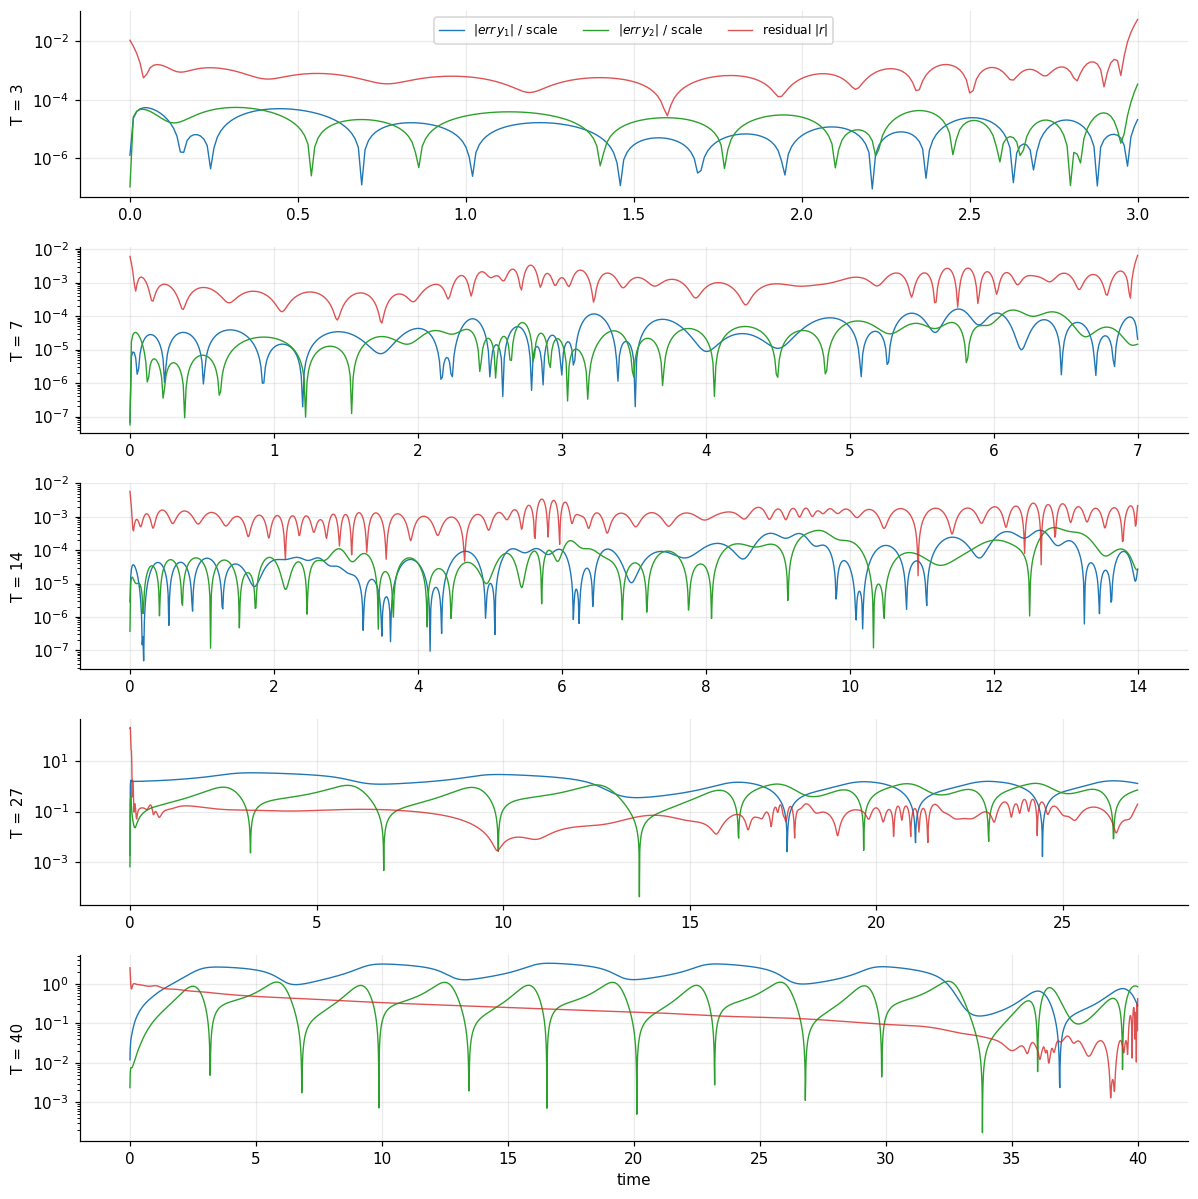

In [9]:
fig, axes = plt.subplots(len(HORIZONS), 1, figsize=(11, 11), sharex=False)
for ax, T in zip(axes, HORIZONS):
    seed = median_seed(summary, T)
    key = f"T{T:g}_seed{seed}"
    t = predictions[f"t_T{T:g}"]
    pw = predictions[f"{key}_pointwise"]
    ax.semilogy(t, pw[:, 0], color="C0", lw=0.9, label="$|err\,y_1|$ / scale")
    ax.semilogy(t, pw[:, 1], color="C2", lw=0.9, label="$|err\,y_2|$ / scale")
    ax.semilogy(t, predictions[f"{key}_residual"], color="C3", lw=0.9,
                alpha=0.8, label="residual $|r|$")
    ax.set_ylabel(f"T = {T:g}")
axes[0].legend(fontsize=8, ncol=3)
axes[-1].set_xlabel("time")
fig.tight_layout()
fig.savefig(FIGURES / "06_error_and_residual.png", bbox_inches="tight")
plt.show()

## Verdict

In [10]:
both = pd.DataFrame({
    "Initial_pass": initial.groupby("horizon").rel_l2.median(),
    "causal": summary.groupby("horizon").rel_l2.median(),
})
both["laps"] = both.index / LAP
both["improvement"] = both.Initial_pass / both.causal
print(both.to_string(float_format=lambda v: f"{v:.3e}"))
print()
print(f"front arrived in {summary.front_arrived.sum()} of {len(summary)} runs")

assert len(summary) == len(tr.HORIZONS) * len(tr.SEEDS), "sweep incomplete"
assert np.isfinite(summary.rel_l2).all()

         Initial_pass    causal      laps  improvement
horizon                                               
3.0         3.768e-05 4.795e-05 4.502e-01    7.860e-01
7.0         6.638e-04 7.632e-05 1.051e+00    8.698e+00
14.0        7.933e-01 2.117e-04 2.101e+00    3.748e+03
27.0        9.044e-01 1.901e+00 4.052e+00    4.757e-01
40.0        9.415e-01 2.044e+00 6.003e+00    4.605e-01

front arrived in 6 of 15 runs


## Conclusions

**Causal weighting moves the cliff from one lap to two, at identical collocation density and
network.** Sub-lap horizons are unharmed (T = 3: parity with Initial_pass at ~5e-5). At one
lap it is ~9x better (7.6e-5 vs 6.6e-4). At T = 14 — total collapse for the unweighted loss,
all seeds — two of three seeds now track the reference through both laps at ~1e-4 to 2e-4
relative L2, a ~4000x improvement of the median, and the fit is visually indistinguishable
from the reference (Figure 4, third panel).

**Where it still fails, it fails detectably, not silently.** The front-crossing cost grows
super-linearly with horizon: ~3.5k Adam steps at half a lap, ~10-30k at one lap, ~60k at two
laps, and beyond the 60,000-step budget at four and six laps. Every T >= 14 run hit the cap
(front_arrived = False); at T = 14 two seeds had effectively crossed anyway and the polish
finished the job, while the third — and all T = 27/40 runs — were caught mid-crossing. The
telemetry (min weight, awake fraction) flags every one of these, whereas Initial_pass
converged its loss and was simply wrong.

**Budget-starved runs are worse than unweighted ones** (rel L2 1.9-2.3 vs ~0.9): the
unweighted impostor at least sits quietly on the equilibrium, while an interrupted front
leaves the tail on an arbitrary wrong trajectory. And the optimiser found the next loophole:
at T = 27/40 the fit satisfies the anchor exactly at t = 0, then jumps to a low-residual
impostor trajectory *in the gap before the first collocation point* (Figure 4, bottom two
panels; the spike at t ~ 0 in Figure 6) — the escape happens where the loss never looks.
Closing one cheat exposed the following one, which is the recurring lesson of this study:
the equation alone admits many solutions, and any unanchored stretch of domain — late times
in Initial_pass, unsampled gaps here — will be exploited.

**The trained object is unchanged in kind**: still a continuous map t -> (y1, y2), queryable
at any time; on success the weights all reach 1 and the objective coincides with the
unweighted Initial_pass loss, so the comparison is of training paths, not of models.

**Standing verdict for the programme**: causality was the right missing ingredient — it is
generic, assumes nothing about the solution, and rescues the method exactly as far as its
optimisation budget can carry the front. But the cost of propagating causality softly, in
training time, grows quickly with the horizon. The discrete-time technique enforces the same
causality *structurally* — each step re-anchored on known states, no front to propagate —
which is the comparison the next study makes.